# BNS vs BHNS: GRB Population Comparison

Side-by-side comparison of GRB class fractions and formation efficiencies for Binary Neutron Stars (BNS) and Black Hole/Neutron Star (BHNS) mergers.

Uses results from `GRB_BNS.ipynb` (Model A, fiducial) and `GRB_BHNS.ipynb` (Model A, BH spin a=0.5).

Run `GRB_BNS.ipynb` and `GRB_BHNS.ipynb` first to generate the `.npy` export files, or run those notebooks to have the variables in memory.

## 1. Load Saved Efficiency Arrays

In [1]:
import numpy as np
import matplotlib.pyplot as plt

metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

bns  = np.load('/Users/josephrodriguez/research visualization/results/eff_BNS.npy')
bhns = np.load('/Users/josephrodriguez/research visualization/results/eff_BHNS.npy')

eff_total_BNS,  eff_short_BNS,  eff_long_BNS                      = bns
(eff_total_BHNS, eff_short_BHNS_a05, eff_long_BHNS_a05,
 eff_nogrb_BHNS, eff_short_BHNS_a07, eff_long_BHNS_a07) = bhns

print('BNS  - total efficiency range:',
      f'{eff_total_BNS[eff_total_BNS>0].min():.2e} to {eff_total_BNS.max():.2e}')
print('BHNS - total efficiency range:',
      f'{eff_total_BHNS[eff_total_BHNS>0].min():.2e} to {eff_total_BHNS.max():.2e}')

BNS  - total efficiency range: 4.79e-07 to 4.37e-06
BHNS - total efficiency range: 3.95e-10 to 1.21e-05


## 2. GRB Class Fractions: BNS vs BHNS

Fraction of all merging systems in each GRB class. BHNS fractions are for assumed BH spin `a = 0.5`.

**Assumptions:**
- **BNS:** Gottlieb et al. (2023) [arXiv:2309.00038] mass and mass-ratio thresholds with $M_{\rm crit} = 2.8\,M_\odot$, $q_{\rm thresh} = 1.2$. The three BNS sub-populations (Short Type I, Short Type II, Long) are working labels from a combined framework, not a direct implementation of either the hybrid or all-BH scenario (see `GRB_BNS.ipynb` for details). Fiducial GRB efficiency $\varepsilon_{\rm GRB} = 1.0$ (every merger launches a jet). Set $\varepsilon_{\rm GRB} < 1$ to account for jet breakout failure or disk evaporation (Gottlieb et al. 2023, Sec. 4.3). See `GRB_CosmicRate.ipynb` for $\varepsilon_{\rm GRB} = 0.7$ sensitivity. No SMNS/stable-NS category.
- **BHNS:** Foucart et al. (2018) [arXiv:1807.00011] Eq. (4) with all four fitted parameters $(\alpha,\beta,\gamma,\delta) = (0.406, 0.139, 0.255, 1.761)$. Mass-dependent NS radius ($R_{1.4} = 12\,\mathrm{km}$, NICER-consistent) and baryon mass correction ($M^b \approx M_g + 0.080\,M_g^2$; Gao et al. 2020), matching the implementation in `GRB_BHNS.ipynb`. A constant $f_{\rm disk} = 0.4$ converts remnant baryon mass to disk mass (midrange estimate; Foucart 2012, Sec. VI; NR range $\sim 1/3$ to $2/3$); the standard approach subtracts dynamical ejecta from $M_{\rm rem}$ (Coughlin et al. 2020; Kawaguchi et al. 2016). See `GRB_BHNS.ipynb` Section 14 for $f_{\rm disk}$ sensitivity. BH spin is not tracked by COMPAS; fractions are conditional on the assumed value. All fractions are STROOPWAFEL-weighted.

In [ ]:
import h5py

# ── BNS: load & classify (Gottlieb M_crit=2.8, q_thresh=1.2) ─────────────
with h5py.File('/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5', 'r') as f:
    _d = f['doubleCompactObjects']
    _m1_bns = _d['M1'][...].squeeze()
    _m2_bns = _d['M2'][...].squeeze()
    _mg_bns = _d['mergesInHubbleTimeFlag'][...].squeeze()
    _w_bns  = _d['weight'][...].squeeze()

_mask_bns = (_mg_bns == 1)
_Mtot_bns = _m1_bns[_mask_bns] + _m2_bns[_mask_bns]
_q_bns    = (np.maximum(_m1_bns[_mask_bns], _m2_bns[_mask_bns]) /
             np.minimum(_m1_bns[_mask_bns], _m2_bns[_mask_bns]))
_wb_bns   = _w_bns[_mask_bns]
_W_bns    = _wb_bns.sum()

_short_bns = ((_Mtot_bns < 2.8) | ((_Mtot_bns >= 2.8) & (_q_bns < 1.2)))
_long_bns  = ((_Mtot_bns >= 2.8) & (_q_bns >= 1.2))

epsilon_grb_BNS = 1.0  # fiducial; see GRB_CosmicRate.ipynb for eps=0.7 sensitivity

_frac_short_raw = 100 * _wb_bns[_short_bns].sum() / _W_bns
_frac_long_raw  = 100 * _wb_bns[_long_bns].sum()  / _W_bns

bns_frac = [
    _frac_short_raw * epsilon_grb_BNS,           # Short cbGRB (weighted)
    _frac_long_raw  * epsilon_grb_BNS,            # Long cbGRB (weighted)
    100.0 * (1.0 - epsilon_grb_BNS),              # No GRB (jet-launch failure)
]

# ── BHNS: load & classify (Foucart et al. 2018, a=0.5) ───────────────────
with h5py.File('/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5', 'r') as f:
    _d = f['doubleCompactObjects']
    _M1       = _d['M1'][...].squeeze()
    _M2       = _d['M2'][...].squeeze()
    _mg_bhns  = _d['mergesInHubbleTimeFlag'][...].squeeze()
    _stype1   = _d['stellarType1'][...].squeeze()
    _w_bhns   = _d['weight'][...].squeeze()

_isBH = (_stype1 == 14)
assert np.all((_stype1 == 14) | (_stype1 == 13)), \
    "Unexpected stellar type in BHNS file: expected only types 13 (NS) and 14 (BH)"
assert _isBH[_mg_bhns == 1].any() and (~_isBH[_mg_bhns == 1]).any(), \
    "BH/NS assignment error: all merging systems have the same stellar type"
_BH   = np.where(_isBH, _M1, _M2)
_NS   = np.where(_isBH, _M2, _M1)
_mask_bhns = (_mg_bhns == 1)
_BH_m, _NS_m = _BH[_mask_bhns], _NS[_mask_bhns]
_wb_bhns = _w_bhns[_mask_bhns]
_W_bhns  = _wb_bhns.sum()

from grb_physics import foucart_disk_mass, F_DISK, MDISK_SHORT, MDISK_LONG

_disk05  = foucart_disk_mass(_BH_m, _NS_m, a_BH=0.5)
_disk07  = foucart_disk_mass(_BH_m, _NS_m, a_BH=0.7)

bhns_frac = [
    100 * _wb_bhns[(_disk05 >= 0.01) & (_disk05 < 0.1)].sum() / _W_bhns,  # Short cbGRB (weighted)
    100 * _wb_bhns[_disk05 >= 0.1].sum()                      / _W_bhns,  # Long cbGRB (weighted)
    100 * _wb_bhns[_disk05 < 0.01].sum()                      / _W_bhns,  # No GRB (weighted)
]

# Spin sensitivity values for annotation (weighted)
_nogrb07 = 100 * _wb_bhns[_disk07 < 0.01].sum()  / _W_bhns
_long07  = 100 * _wb_bhns[_disk07 >= 0.1].sum()  / _W_bhns

print(f"BNS:  Short: {bns_frac[0]:.1f}%  Long: {bns_frac[1]:.1f}%  No GRB: {bns_frac[2]:.1f}%")
print(f"BHNS: Short: {bhns_frac[0]:.1f}%  Long: {bhns_frac[1]:.1f}%  No GRB: {bhns_frac[2]:.1f}%")
print(f"BHNS a=0.7:  No GRB: {_nogrb07:.1f}%  Long: {_long07:.1f}%")

BNS:  Short: 74.6%  Long: 25.4%  No GRB: 0.0%
BHNS: Short: 11.1%  Long: 0.0%  No GRB: 88.9%
BHNS a=0.7:  No GRB: 74.9%  Long: 0.0%


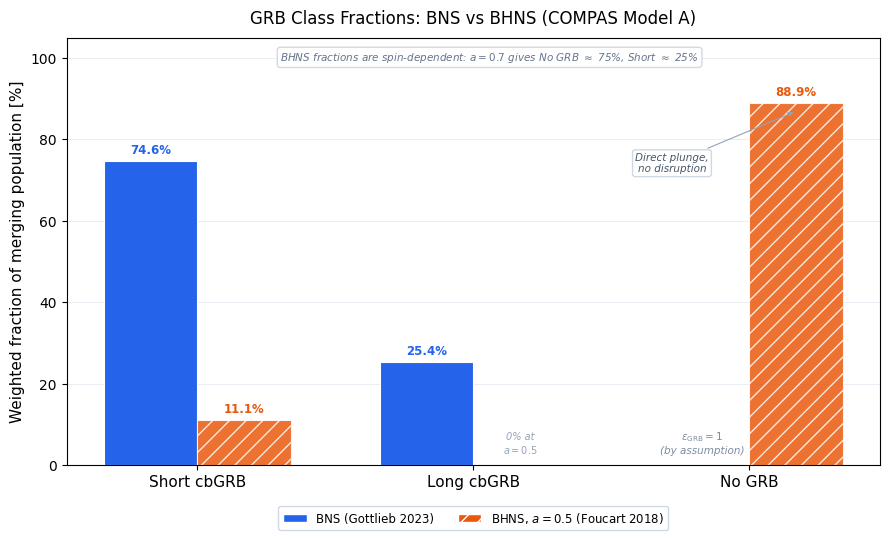

In [3]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 5.5))

labels = ['Short cbGRB', 'Long cbGRB', 'No GRB']
x = np.arange(len(labels))
w = 0.34

col_bns  = '#2563EB'
col_bhns = '#EA580C'

bars_bns  = ax.bar(x - w/2, bns_frac,  w, color=col_bns, edgecolor='white',
                   linewidth=0.8, zorder=2, label='BNS')
bars_bhns = ax.bar(x + w/2, bhns_frac, w, color=col_bhns, edgecolor='white',
                   linewidth=0.8, zorder=2, hatch='//', alpha=0.85,
                   label='BHNS ($a=0.5$)')

for bar in bars_bns:
    h = bar.get_height()
    if h > 0.5:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1.2,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8.5,
                color=col_bns, fontweight='bold')

for bar in bars_bhns:
    h = bar.get_height()
    if h > 0.5:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1.2,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8.5,
                color=col_bhns, fontweight='bold')

ax.annotate('Direct plunge,\nno disruption',
            xy=(x[2] + w/2, bhns_frac[2] - 2), xytext=(x[1] + 0.72, 72),
            fontsize=7.5, color='#475569', style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color='#94A3B8', lw=0.8),
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor='#CBD5E1', alpha=0.92))

ax.text(x[1] + w/2, 2.5,
        '0% at\n$a=0.5$', ha='center', va='bottom',
        fontsize=7, color='#94A3B8', style='italic')

ax.text(x[2] - w/2, 2.5,
        '$\\varepsilon_{\\rm GRB}=1$\n(by assumption)', ha='center', va='bottom',
        fontsize=7.5, color='#7C8DA0', style='italic')

ax.set_xlabel('')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Weighted fraction of merging population [%]', fontsize=11)
ax.set_ylim(0, 105)

ax.set_title('GRB Class Fractions: BNS vs BHNS (COMPAS Model A)',
             fontsize=12, pad=10)

ax.grid(which='major', axis='y', color='#E2E8F0', linewidth=0.5,
        linestyle='-', zorder=0)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=col_bns,  edgecolor='white', label='BNS (Gottlieb 2023)'),
    Patch(facecolor=col_bhns, edgecolor='white', hatch='//',
          label='BHNS, $a=0.5$ (Foucart 2018)'),
]
ax.legend(handles=legend_elements, fontsize=8.5, loc='upper center',
          ncol=2, bbox_to_anchor=(0.5, -0.08),
          frameon=True, framealpha=0.92, fancybox=True, edgecolor='#CBD5E1')

ax.text(0.52, 0.97,
        f'BHNS fractions are spin-dependent: '
        f'$a=0.7$ gives No GRB $\\approx$ {_nogrb07:.0f}%, Short $\\approx$ {100-_nogrb07-_long07:.0f}%',
        transform=ax.transAxes, fontsize=7.5, color='#64748B',
        ha='center', va='top', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#CBD5E1', alpha=0.9))

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/comparison_grb_fractions.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 3. Formation Efficiency vs Metallicity

Formation efficiency $\eta(Z)$ (number of merging compact objects per solar mass of star formation) as a function of progenitor metallicity, for BNS (blue) and BHNS (orange), broken down by GRB class.

BNS efficiency is relatively flat across metallicity, consistent with Neijssel et al. (2019): NS progenitors have lower mass-loss rates, so their yield is less sensitive to $Z$. BHNS efficiency peaks at sub-solar metallicities and drops sharply near $Z_\odot$, because higher wind mass-loss at solar $Z$ produces smaller BH remnants with larger natal kicks that disrupt binaries.

> **Note:** BHNS Long cbGRB efficiency is identically zero at $a=0.5$ (no systems produce $M_\mathrm{disk} \geq 0.1\,M_\odot$), so it is omitted from the plot.

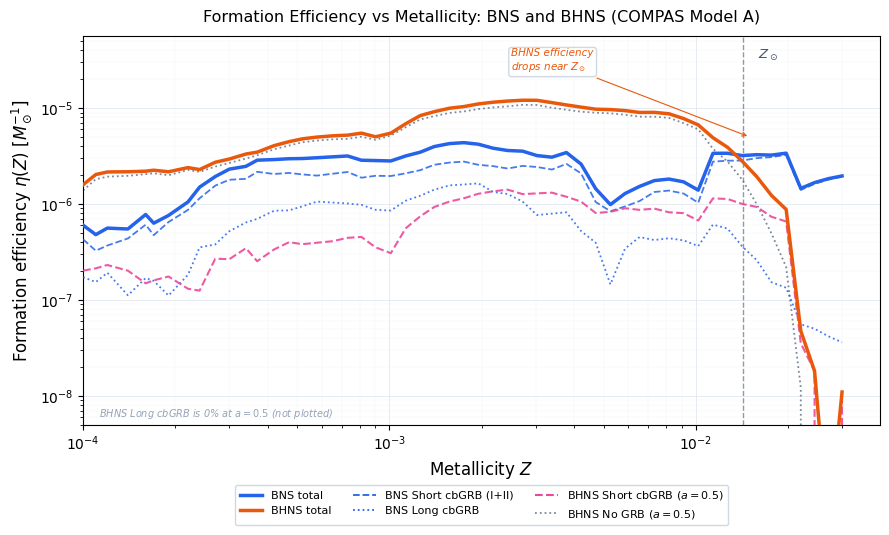

In [4]:
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory as _btf

fig, ax = plt.subplots(figsize=(9, 5.5))

col_bns  = '#2563EB'
col_bhns = '#EA580C'
col_bhns_short = '#EC4899'
col_nogrb = '#64748B'

ax.plot(metallicityGrid, eff_total_BNS,  color=col_bns,  lw=2.5, zorder=4)
ax.plot(metallicityGrid, eff_total_BHNS, color=col_bhns, lw=2.5, zorder=4)

ax.plot(metallicityGrid, eff_short_BNS,  color=col_bns, lw=1.3, ls='--',
        alpha=0.85, zorder=3)
ax.plot(metallicityGrid, eff_long_BNS,   color=col_bns, lw=1.3, ls=':',
        alpha=0.85, zorder=3)

ax.plot(metallicityGrid, eff_short_BHNS_a05, color=col_bhns_short, lw=1.5,
        ls='--', alpha=0.9, zorder=3)
ax.plot(metallicityGrid, eff_nogrb_BHNS, color=col_nogrb, lw=1.3, ls=':',
        alpha=0.85, zorder=2)

ax.grid(which='major', color='#E2E8F0', linewidth=0.6, linestyle='-')
ax.grid(which='minor', color='#F1F5F9', linewidth=0.3, linestyle='-')
ax.set_axisbelow(True)

ax.set_xscale('log')
ax.set_yscale('log')
ax.margins(y=0.15)
ax.set_ylim(bottom=5e-9)
ax.set_xlim(left=1e-4)
ax.set_xlabel('Metallicity $Z$', fontsize=12)
ax.set_ylabel(r'Formation efficiency $\eta(Z)$ [$M_\odot^{-1}$]', fontsize=12)
ax.set_title('Formation Efficiency vs Metallicity: BNS and BHNS (COMPAS Model A)',
             fontsize=11.5, pad=10)

_trans_x = _btf(ax.transData, ax.transAxes)
ax.axvline(0.0142, color='#475569', lw=1.0, ls='--', zorder=1, alpha=0.6)
ax.text(0.0142 * 1.12, 0.97, r'$Z_\odot$', fontsize=9.5, color='#475569',
        va='top', ha='left', transform=_trans_x, fontweight='bold')

ax.annotate('BHNS efficiency\ndrops near $Z_\\odot$',
            xy=(0.015, 5e-6), xytext=(0.0025, 2.5e-5),
            fontsize=7.5, color=col_bhns, style='italic',
            arrowprops=dict(arrowstyle='->', color=col_bhns, lw=0.8),
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor='#CBD5E1', alpha=0.92))

legend_elements = [
    Line2D([0], [0], color=col_bns,  lw=2.5, label='BNS total'),
    Line2D([0], [0], color=col_bhns, lw=2.5, label='BHNS total'),
    Line2D([0], [0], color=col_bns,  lw=1.3, ls='--', label='BNS Short cbGRB (I+II)'),
    Line2D([0], [0], color=col_bns,  lw=1.3, ls=':',  label='BNS Long cbGRB'),
    Line2D([0], [0], color=col_bhns_short, lw=1.5, ls='--', label='BHNS Short cbGRB ($a=0.5$)'),
    Line2D([0], [0], color=col_nogrb, lw=1.3, ls=':',  alpha=0.85,
           label='BHNS No GRB ($a=0.5$)'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='upper center',
          ncol=3, bbox_to_anchor=(0.5, -0.14),
          frameon=True, framealpha=0.92, fancybox=True, edgecolor='#CBD5E1')

ax.text(0.02, 0.02, 'BHNS Long cbGRB is 0% at $a=0.5$ (not plotted)',
        transform=ax.transAxes, fontsize=7, color='#94A3B8', style='italic')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/comparison_efficiency.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 4. Metallicity vs Delay Time

Scatter plot of progenitor metallicity versus total delay time ($t_\mathrm{form} + t_c$) for each GRB/merger class in both BNS and BHNS populations. The delay time distribution is roughly flat-in-the-log for all DCOs (Peters 1964; Neijssel et al. 2019 Fig. 3), and is not very sensitive to metallicity.

Key features:
- **BNS systems span all metallicities**, reflecting their metallicity-insensitive formation efficiency.
- **BHNS systems are absent above $Z \gtrsim 0.02$**, consistent with the sharp drop in BHNS formation efficiency near $Z_\odot$ seen in the previous plot.
- **BHNS Long cbGRB** is identically zero at $a = 0.5$ and is omitted.

> **Note on jitter:** Metallicity values in COMPAS output sit on a discrete grid of 53 points. To prevent overplotting, each point's metallicity is multiplied by $10^U$ where $U \sim \mathrm{Uniform}(-0.04, 0.04)$, a $\pm 4\%$ perturbation in $\log_{10}(Z)$. This is purely cosmetic and does not affect any computed quantities.

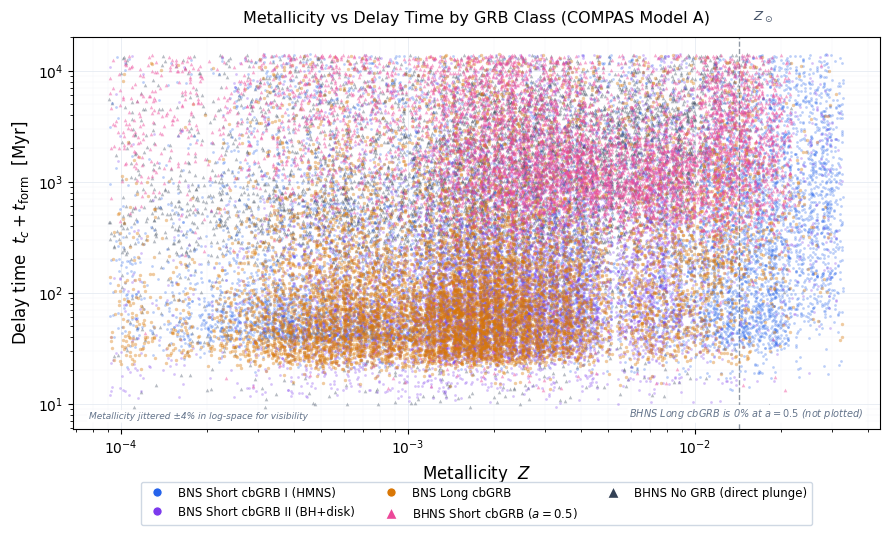

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Load BNS raw data ─────────────────────────────────────────────────────────
with h5py.File('/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5', 'r') as f:
    _d = f['doubleCompactObjects']
    _bns_m1   = _d['M1'][...].squeeze()
    _bns_m2   = _d['M2'][...].squeeze()
    _bns_mg   = _d['mergesInHubbleTimeFlag'][...].squeeze()
    _bns_Z    = _d['Metallicity1'][...].squeeze()
    _bns_tc   = _d['tc'][...].squeeze()
    _bns_tform= _d['tform'][...].squeeze()
    _bns_w    = _d['weight'][...].squeeze()

_bmask      = (_bns_mg == 1)
_bns_Mtot   = (_bns_m1 + _bns_m2)[_bmask]
_bns_q      = (np.maximum(_bns_m1, _bns_m2) / np.minimum(_bns_m1, _bns_m2))[_bmask]
_bns_delay  = (_bns_tc + _bns_tform)[_bmask]       # Myr
_bns_Zval   = _bns_Z[_bmask]
_bns_weight = _bns_w[_bmask]

# Gottlieb classification
_bns_shortI  = (_bns_Mtot < 2.8)
_bns_shortII = (_bns_Mtot >= 2.8) & (_bns_q < 1.2)
_bns_long    = (_bns_Mtot >= 2.8) & (_bns_q >= 1.2)

# ── Load BHNS raw data ────────────────────────────────────────────────────────
with h5py.File('/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5', 'r') as f:
    _d = f['doubleCompactObjects']
    _bh_m1    = _d['M1'][...].squeeze()
    _bh_m2    = _d['M2'][...].squeeze()
    _bh_mg    = _d['mergesInHubbleTimeFlag'][...].squeeze()
    _bh_stype = _d['stellarType1'][...].squeeze()
    _bh_Z     = _d['Metallicity1'][...].squeeze()
    _bh_tc    = _d['tc'][...].squeeze()
    _bh_tform = _d['tform'][...].squeeze()
    _bh_w     = _d['weight'][...].squeeze()

_hhmask    = (_bh_mg == 1)
_isBH      = (_bh_stype == 14)
# Sanity-check: every row must be either BH (14) or NS (13)
assert np.all((_bh_stype == 14) | (_bh_stype == 13)), \
    "Unexpected stellar type in BHNS file: expected only types 13 (NS) and 14 (BH)"
assert _isBH[_hhmask].any() and (~_isBH[_hhmask]).any(), \
    "BH/NS assignment error: all systems have the same stellar type"
_BH_m      = np.where(_isBH, _bh_m1, _bh_m2)[_hhmask]
_NS_m      = np.where(_isBH, _bh_m2, _bh_m1)[_hhmask]
_bh_delay  = (_bh_tc + _bh_tform)[_hhmask]         # Myr
_bh_Zval   = _bh_Z[_hhmask]
_bh_weight = _bh_w[_hhmask]

_disk = foucart_disk_mass(_BH_m, _NS_m, a_BH=0.5)
_bh_short = (_disk >= 0.01) & (_disk < 0.1)
_bh_long  = (_disk >= 0.1)
_bh_nogrb = (_disk < 0.01)

# ── Downsample for readability ────────────────────────────────────────────────
rng = np.random.default_rng(42)

def weighted_sample(mask, weight, n_target=12000):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return idx
    w = weight[idx]
    if w.sum() == 0:
        return idx[:min(n_target, len(idx))]   # fall back to unweighted if all weights are zero
    w = w / w.sum()
    n = min(n_target, len(idx))
    return rng.choice(idx, size=n, replace=False, p=w)

_s_shortI    = weighted_sample(_bns_shortI,  _bns_weight, 10000)
_s_shortII   = weighted_sample(_bns_shortII, _bns_weight, 10000)
_s_long_bns  = weighted_sample(_bns_long,    _bns_weight, 10000)
_s_bh_short  = weighted_sample(_bh_short,    _bh_weight,  6000)
_s_bh_long   = weighted_sample(_bh_long,     _bh_weight,  6000)
_s_bh_nogrb  = weighted_sample(_bh_nogrb,    _bh_weight,  6000)

# ── Log-space jitter to break discrete metallicity grid stripes ───────────────
_jitter_scale = 0.04   # ±4% in log10(Z)

def log_jitter(Z, scale=_jitter_scale):
    return Z * 10 ** rng.uniform(-scale, scale, size=len(Z))

_jZ_shortI    = log_jitter(_bns_Zval[_s_shortI])
_jZ_shortII   = log_jitter(_bns_Zval[_s_shortII])
_jZ_long_bns  = log_jitter(_bns_Zval[_s_long_bns])
_jZ_bh_short  = log_jitter(_bh_Zval[_s_bh_short])
_jZ_bh_long   = log_jitter(_bh_Zval[_s_bh_long])
_jZ_bh_nogrb  = log_jitter(_bh_Zval[_s_bh_nogrb])

# Color palette, perceptually distinct across all 5 classes
C_shortI   = '#2563EB'  # vivid blue:   BNS Short cbGRB I  (HMNS)
C_shortII  = '#7C3AED'  # purple:       BNS Short cbGRB II (BH+disk)
C_bns_long = '#D97706'  # amber:        BNS Long cbGRB
C_bh_short = '#EC4899'  # pink:         BHNS Short cbGRB (small disk)
C_bh_long  = '#16A34A'  # green:        BHNS Long cbGRB (Foucart)
C_nogrb    = '#334155'  # dark slate:   BHNS No GRB (direct plunge)

from matplotlib.transforms import blended_transform_factory as _btf

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(_jZ_bh_nogrb, _bh_delay[_s_bh_nogrb],
           c=C_nogrb, s=7, alpha=0.35, linewidths=0,
           rasterized=True, marker='^', zorder=1)

kw_bns = dict(s=4, alpha=0.30, linewidths=0, rasterized=True, marker='o', zorder=3)
ax.scatter(_jZ_shortI,   _bns_delay[_s_shortI],   c=C_shortI,   **kw_bns)
ax.scatter(_jZ_shortII,  _bns_delay[_s_shortII],  c=C_shortII,  **kw_bns)
ax.scatter(_jZ_long_bns, _bns_delay[_s_long_bns], c=C_bns_long,
           s=6, alpha=0.38, linewidths=0, rasterized=True, marker='o', zorder=3)

ax.scatter(_jZ_bh_short, _bh_delay[_s_bh_short],
           c=C_bh_short, s=7, alpha=0.45, linewidths=0,
           rasterized=True, marker='^', zorder=3)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Metallicity  $Z$', fontsize=12)
ax.set_ylabel(r'Delay time  $t_c + t_\mathrm{form}$  [Myr]', fontsize=12)
ax.set_title('Metallicity vs Delay Time by GRB Class (COMPAS Model A)',
             fontsize=11.5, pad=10)

ax.grid(which='major', color='#E2E8F0', linewidth=0.5, linestyle='-', zorder=0)
ax.grid(which='minor', color='#F1F5F9', linewidth=0.3, linestyle='-', zorder=0)
ax.set_axisbelow(True)
ax.tick_params(labelsize=10)

ax.text(0.02, 0.02, f'Metallicity jittered ±{_jitter_scale*100:.0f}% in log-space for visibility',
        transform=ax.transAxes, fontsize=6.5, color='#64748B', ha='left', va='bottom',
        style='italic',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=1.0))

ax.text(0.98, 0.02, 'BHNS Long cbGRB is 0% at $a=0.5$ (not plotted)',
        transform=ax.transAxes, fontsize=7, color='#64748B', ha='right', va='bottom',
        style='italic',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=1.0))

_trans_x = _btf(ax.transData, ax.transAxes)
ax.axvline(0.0142, color='#475569', lw=1.0, ls='--', zorder=2, alpha=0.6)
ax.text(0.0142 * 1.12, 1.03, r'$Z_\odot$', fontsize=9.5, color='#475569',
        va='bottom', ha='left', transform=_trans_x, fontweight='bold')

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_shortI,   markersize=7, label='BNS Short cbGRB I (HMNS)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_shortII,  markersize=7, label='BNS Short cbGRB II (BH+disk)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_bns_long, markersize=7, label='BNS Long cbGRB'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor=C_bh_short, markersize=8, label='BHNS Short cbGRB ($a=0.5$)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor=C_nogrb,    markersize=8, label='BHNS No GRB (direct plunge)'),
]
ax.legend(handles=legend_elements, fontsize=8.5, framealpha=0.92,
          edgecolor='#CBD5E1', loc='upper center',
          bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/metallicity_vs_delaytime.png',
            dpi=150, bbox_inches='tight')
plt.show()